In [230]:
# import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score, learning_curve

In [2]:
# load my dataset
df = pd.read_csv("Financial_Risk_Assessment.csv")

In [3]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Risk Rating']
)
print(df_train.shape)
print(df_test.shape)

(12000, 20)
(3000, 20)


# Describing the raw data 

In [5]:
# basic information
print("Dataset Info:")
df_train.info()     

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 8061 to 1568
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    12000 non-null  int64  
 1   Gender                 12000 non-null  object 
 2   Education Level        12000 non-null  object 
 3   Marital Status         12000 non-null  object 
 4   Income                 10212 non-null  float64
 5   Credit Score           10181 non-null  float64
 6   Loan Amount            10195 non-null  float64
 7   Loan Purpose           12000 non-null  object 
 8   Employment Status      12000 non-null  object 
 9   Years at Current Job   12000 non-null  int64  
 10  Payment History        12000 non-null  object 
 11  Debt-to-Income Ratio   12000 non-null  float64
 12  Assets Value           10209 non-null  float64
 13  Number of Dependents   10233 non-null  float64
 14  City                   12000 non-null  obje

In [6]:
# dimensionality
print(f"Number of Samples (rows): {df_train.shape[0]}")
print(f"Number of Features (columns): {df_train.shape[1]}")

Number of Samples (rows): 12000
Number of Features (columns): 20


In [7]:
# feature types
print("Feature Data Types:")
print(df_train.dtypes.value_counts())

Feature Data Types:
object     10
float64     7
int64       3
Name: count, dtype: int64


In [84]:
df_train.dtypes

Age                        int64
Gender                    object
Education Level           object
Marital Status            object
Income                   float64
Credit Score             float64
Loan Amount              float64
Loan Purpose              object
Employment Status         object
Years at Current Job       int64
Payment History           object
Debt-to-Income Ratio     float64
Assets Value             float64
Number of Dependents     float64
City                      object
State                     object
Country                   object
Previous Defaults        float64
Marital Status Change      int64
Risk Rating                int64
dtype: object

In [8]:
# check missing values
print("Missing Values per Column:")
print(df_train.isnull().sum())

Missing Values per Column:
Age                         0
Gender                      0
Education Level             0
Marital Status              0
Income                   1788
Credit Score             1819
Loan Amount              1805
Loan Purpose                0
Employment Status           0
Years at Current Job        0
Payment History             0
Debt-to-Income Ratio        0
Assets Value             1791
Number of Dependents     1767
City                        0
State                       0
Country                     0
Previous Defaults        1807
Marital Status Change       0
Risk Rating                 0
dtype: int64


In [9]:
# calculating percentage of missing values for each column
missing_percent = df_train.isnull().mean() * 100

print("Percentage of Missing Values per Column:")
print(missing_percent.sort_values(ascending=False))

Percentage of Missing Values per Column:
Credit Score             15.158333
Previous Defaults        15.058333
Loan Amount              15.041667
Assets Value             14.925000
Income                   14.900000
Number of Dependents     14.725000
Age                       0.000000
Marital Status Change     0.000000
Country                   0.000000
State                     0.000000
City                      0.000000
Payment History           0.000000
Debt-to-Income Ratio      0.000000
Gender                    0.000000
Years at Current Job      0.000000
Employment Status         0.000000
Loan Purpose              0.000000
Marital Status            0.000000
Education Level           0.000000
Risk Rating               0.000000
dtype: float64


In [10]:
# basic check for outliers using IQR
numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
outliers = {}
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = ((df_train[col] < (Q1 - 1.5 * IQR)) | (df_train[col] > (Q3 + 1.5 * IQR))).sum()
    outliers[col] = outlier_count

print("Possible Outliers per Numeric Column:")
print(outliers)

Possible Outliers per Numeric Column:
{'Age': 0, 'Income': 0, 'Credit Score': 0, 'Loan Amount': 0, 'Years at Current Job': 0, 'Debt-to-Income Ratio': 0, 'Assets Value': 0, 'Number of Dependents': 0, 'Previous Defaults': 0, 'Marital Status Change': 0}


In [11]:
# target variable info 
print("Target Variable: risk_rating")
print("Unique classes and their counts:")
print(df_train['Risk Rating'].value_counts())

Target Variable: risk_rating
Unique classes and their counts:
Risk Rating
Low       7200
Medium    3600
High      1200
Name: count, dtype: int64


In [12]:
# unique values per column 
print("Unique values per column:")
df_train.nunique()

Unique values per column:


Age                         52
Gender                       3
Education Level              4
Marital Status               4
Income                    9689
Credit Score               200
Loan Amount               9094
Loan Purpose                 4
Employment Status            3
Years at Current Job        20
Payment History              4
Debt-to-Income Ratio     12000
Assets Value             10022
Number of Dependents         5
City                      8892
State                       59
Country                    243
Previous Defaults            5
Marital Status Change        3
Risk Rating                  3
dtype: int64

# Visualizations (EDA)

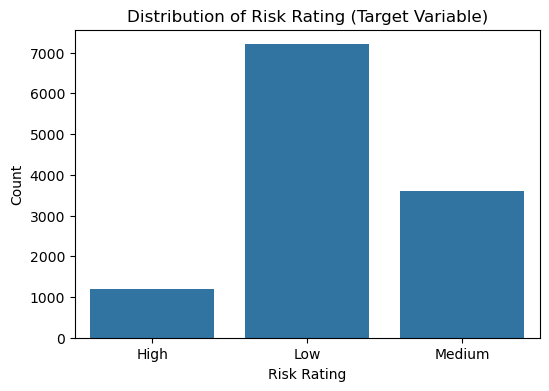

In [25]:
# target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Risk Rating', data=df_train)
plt.title("Distribution of Risk Rating (Target Variable)")
plt.xlabel("Risk Rating")
plt.ylabel("Count")
plt.show()

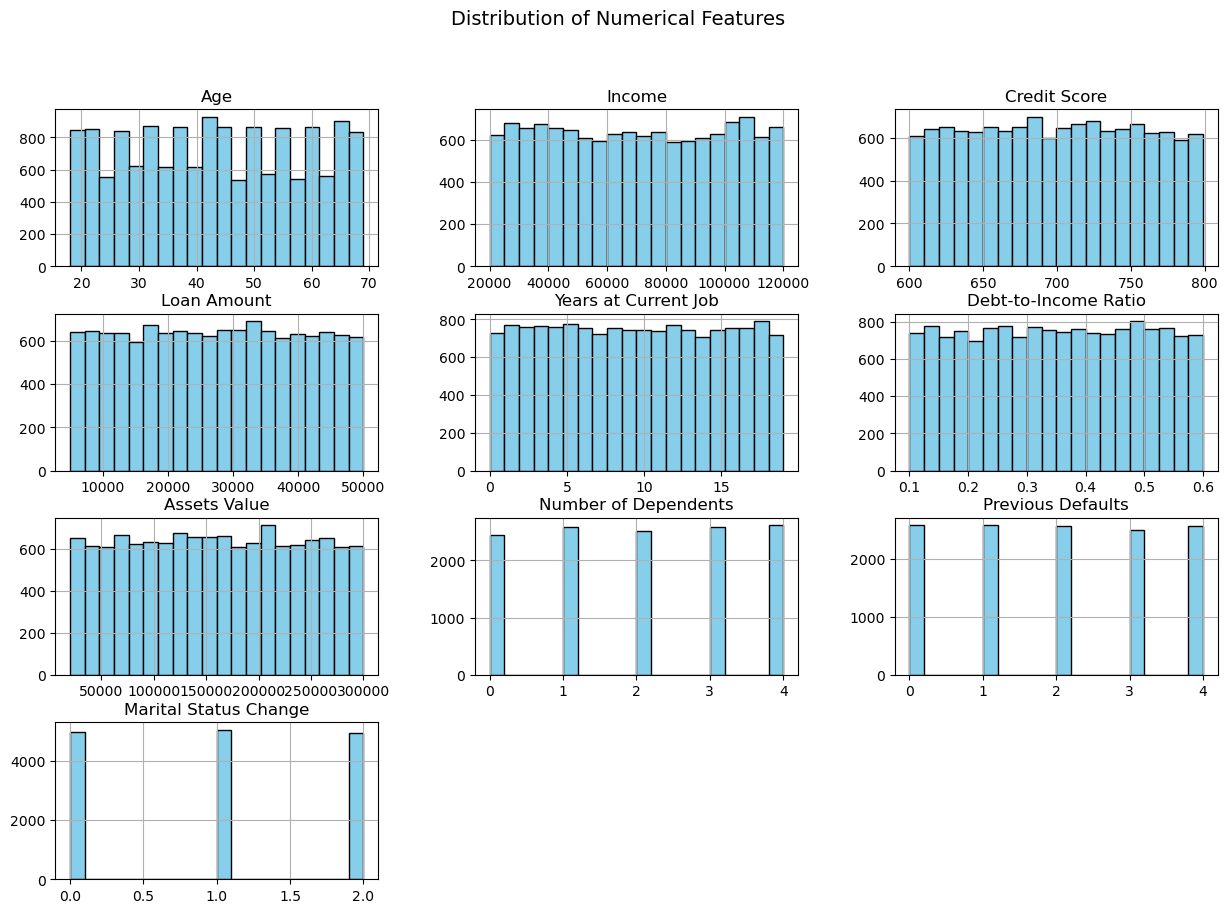

In [47]:
# numerical features distribution

numeric_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=20, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

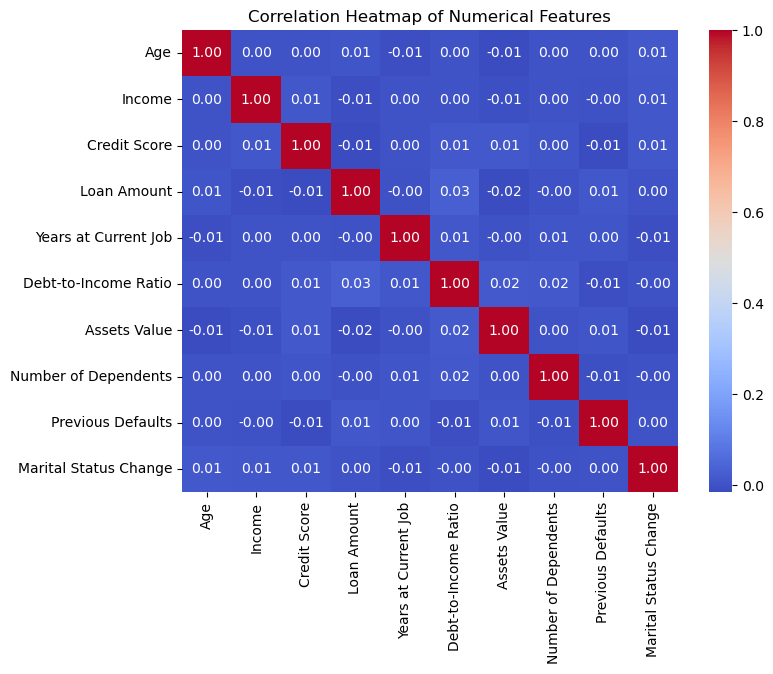

In [29]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_train[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

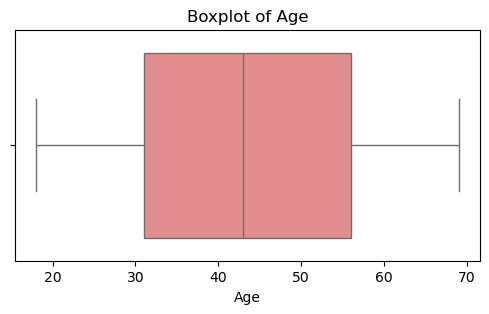

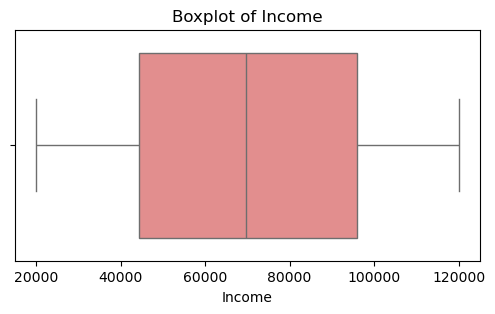

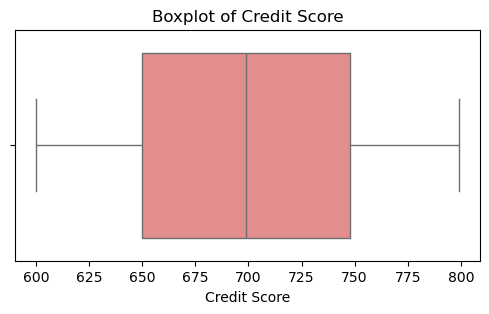

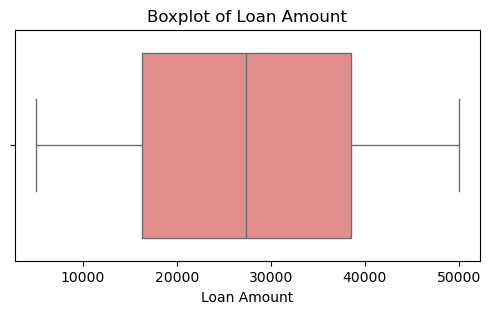

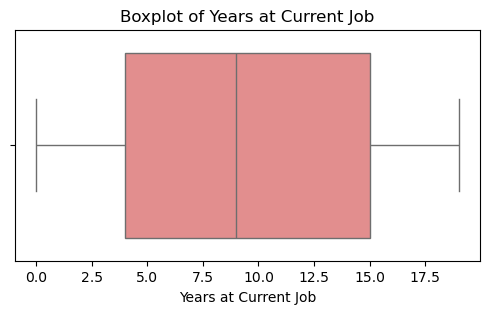

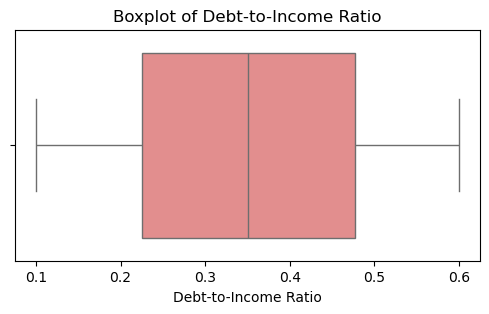

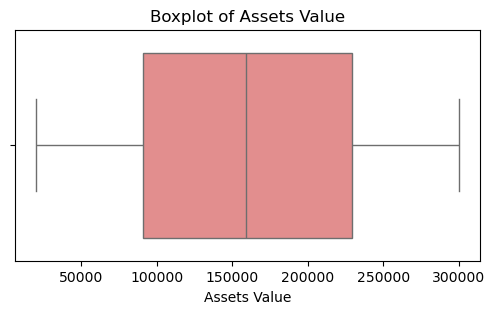

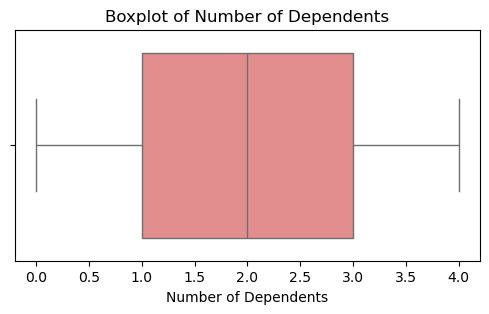

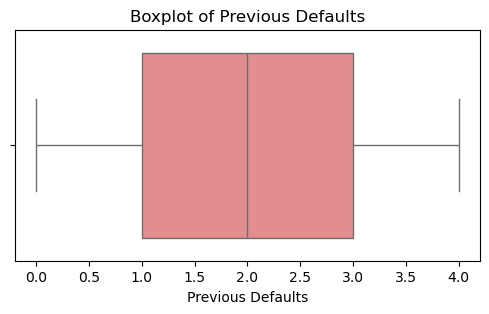

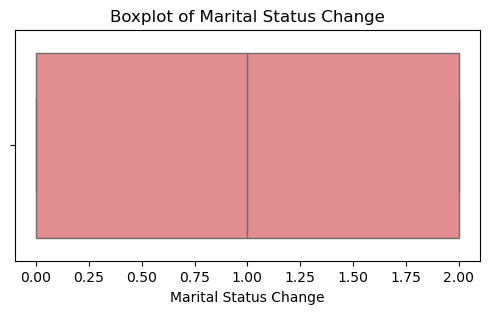

In [31]:
# boxplots to detect outliers
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_train[col], color='lightcoral')
    plt.title(f"Boxplot of {col}")
    plt.show()

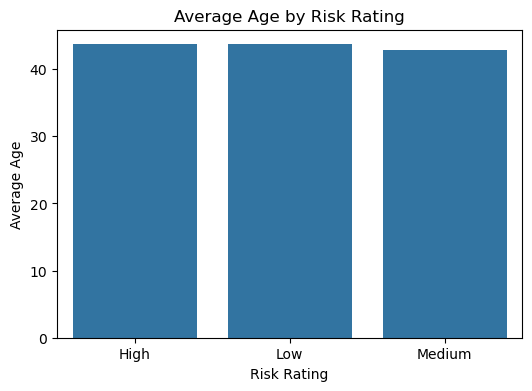

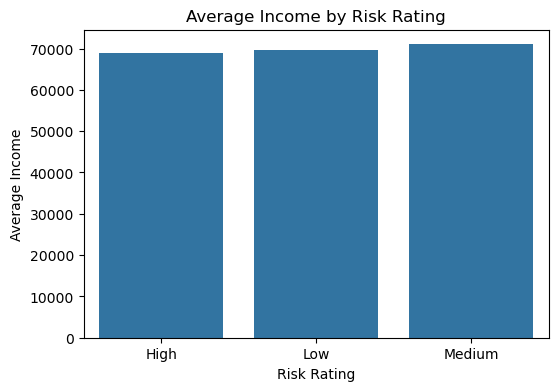

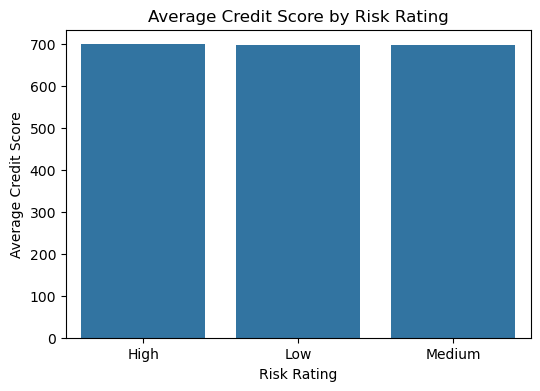

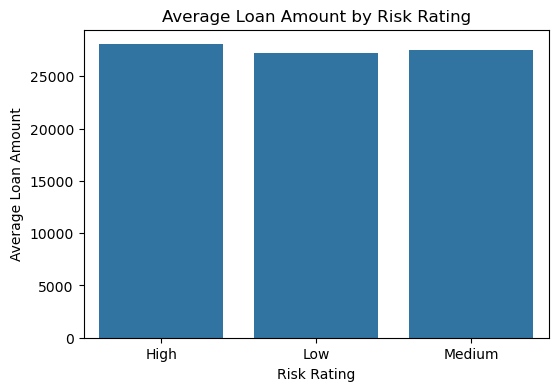

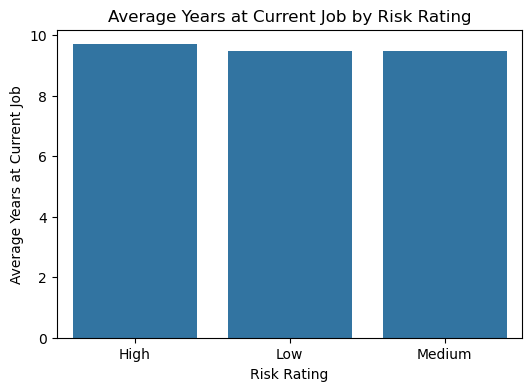

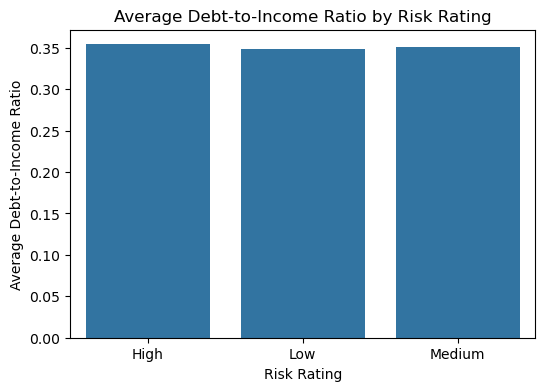

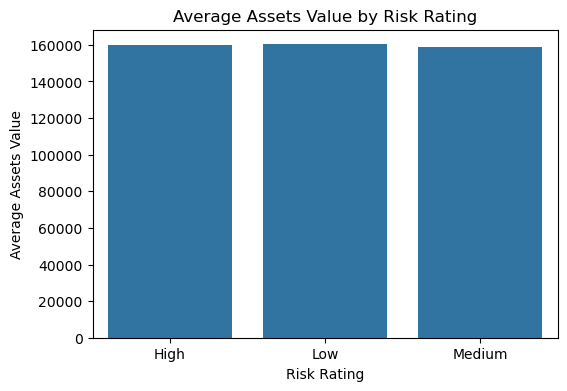

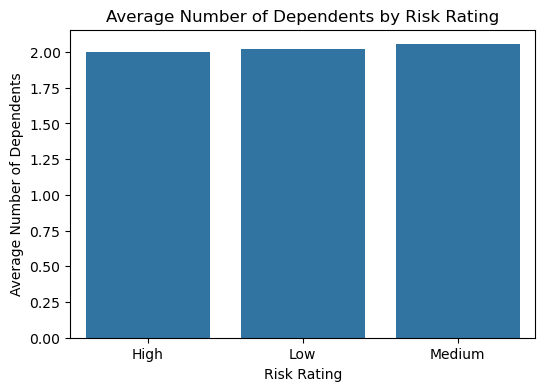

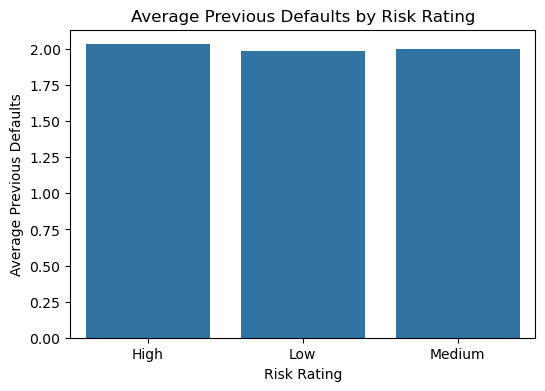

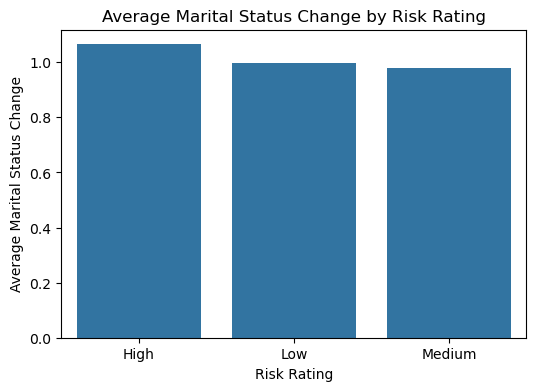

In [33]:
# Plot each feature vs risk_rating
for feature in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(x='Risk Rating', y=feature, data=df_train, estimator='mean', errorbar=None)
    plt.title(f"Average {feature} by Risk Rating")
    plt.xlabel("Risk Rating")
    plt.ylabel(f"Average {feature}")
    plt.show()

In [35]:
categorical_cols = df_train.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Gender', 'Education Level', 'Marital Status', 'Loan Purpose',
       'Employment Status', 'Payment History', 'City', 'State', 'Country',
       'Risk Rating'],
      dtype='object')


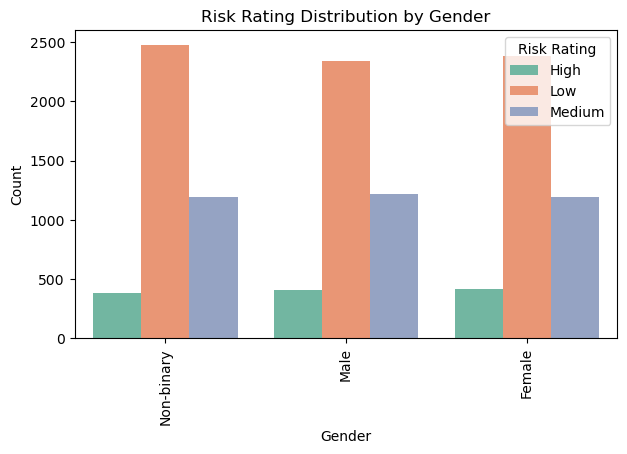

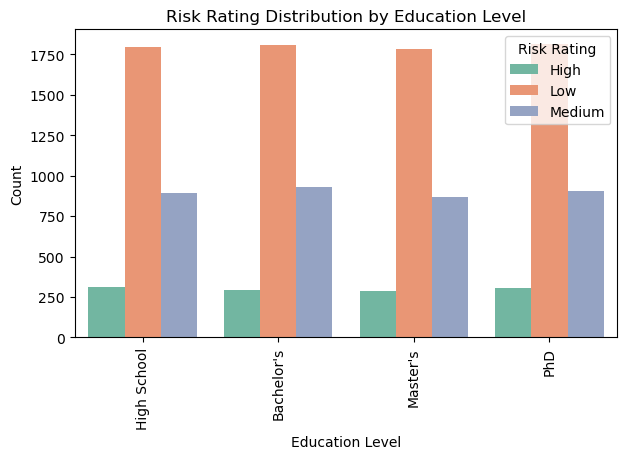

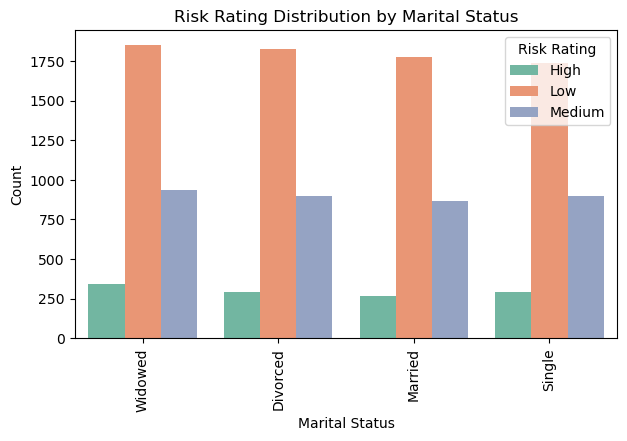

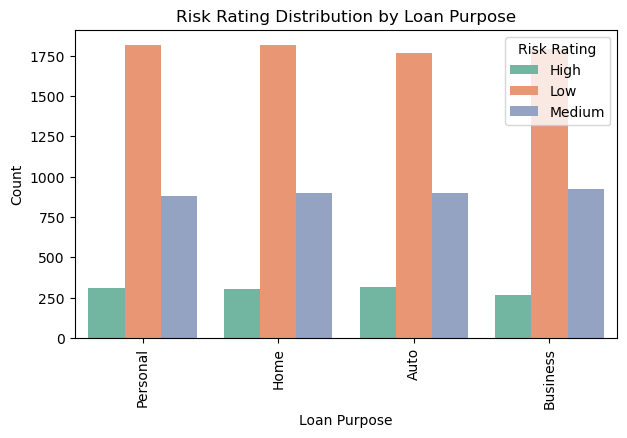

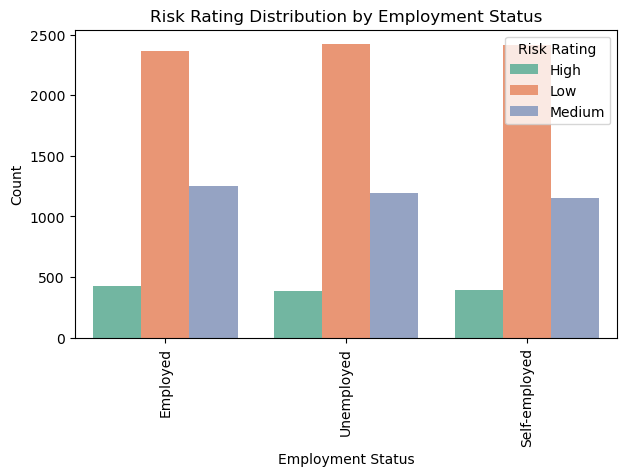

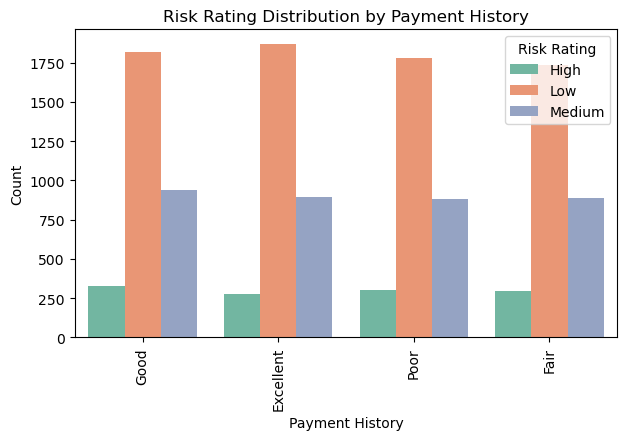

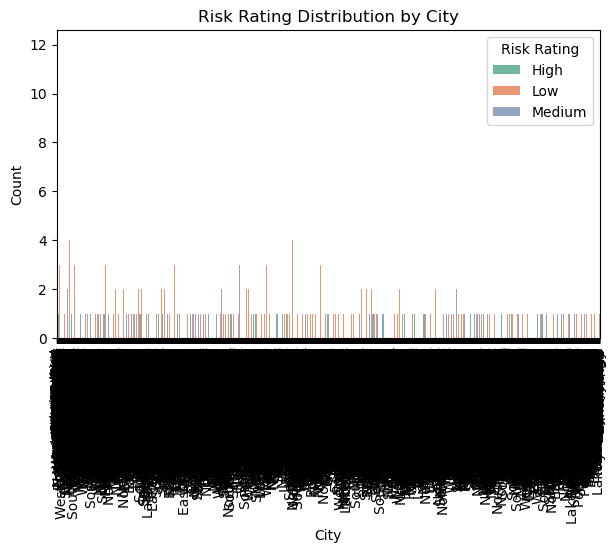

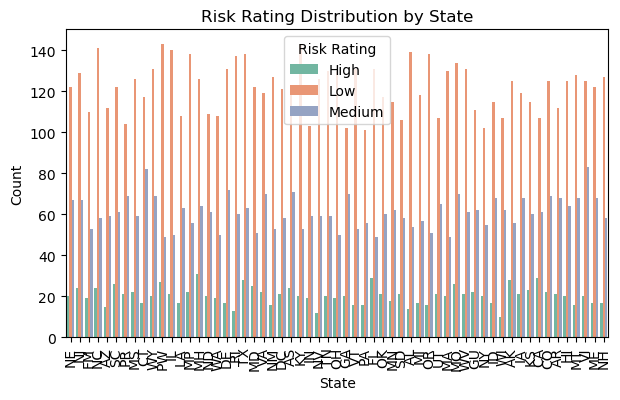

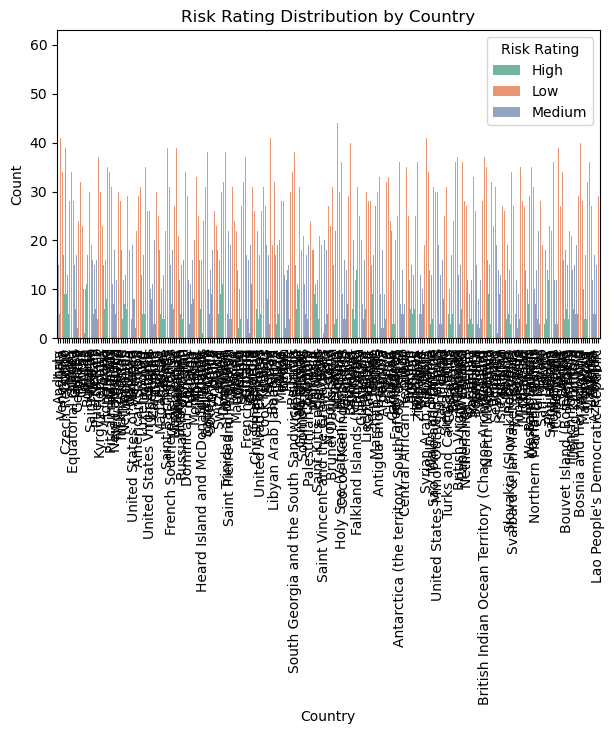

In [37]:
for col in categorical_cols:
    if col != 'Risk Rating':  # skip the target
        plt.figure(figsize=(7,4))
        sns.countplot(x=col, hue='Risk Rating', data=df_train, palette='Set2')
        plt.title(f"Risk Rating Distribution by {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend(title="Risk Rating")
        plt.xticks(rotation=90)
        plt.show()

# Data Preparation

In [24]:
# encode the target column
mapping = {"Low": 0, "Medium": 1, "High": 2}
df_train['Risk Rating']= df_train['Risk Rating'].map(mapping)

In [26]:
# get the numerical columns only from the training data
num_cols = df_train.select_dtypes(include=['int64', 'float64']).columns

In [60]:
from sklearn.impute import KNNImputer
knn_cols = ["Income", "Credit Score", "Loan Amount", "Assets Value"]
knn_imputer = KNNImputer(n_neighbors=5)

df_train[knn_cols] = knn_imputer.fit_transform(df_train[knn_cols])

In [62]:
df_test[knn_cols] = knn_imputer.transform(df_test[knn_cols])

In [64]:
from sklearn.impute import SimpleImputer

mode_imputer = SimpleImputer(strategy='most_frequent')

mode_cols = ["Number of Dependents", "Previous Defaults"]
df_train[mode_cols] = mode_imputer.fit_transform(df_train[mode_cols])
df_test[mode_cols] = mode_imputer.transform(df_test[mode_cols])


In [ ]:
# check if the nulls are removed

In [72]:
df_train.isna().sum()

Age                      0
Gender                   0
Education Level          0
Marital Status           0
Income                   0
Credit Score             0
Loan Amount              0
Loan Purpose             0
Employment Status        0
Years at Current Job     0
Payment History          0
Debt-to-Income Ratio     0
Assets Value             0
Number of Dependents     0
City                     0
State                    0
Country                  0
Previous Defaults        0
Marital Status Change    0
Risk Rating              0
dtype: int64

In [74]:
df_test.isna().sum()

Age                      0
Gender                   0
Education Level          0
Marital Status           0
Income                   0
Credit Score             0
Loan Amount              0
Loan Purpose             0
Employment Status        0
Years at Current Job     0
Payment History          0
Debt-to-Income Ratio     0
Assets Value             0
Number of Dependents     0
City                     0
State                    0
Country                  0
Previous Defaults        0
Marital Status Change    0
Risk Rating              0
dtype: int64

In [ ]:
# see howb the data looks after null handling to make sure i didnt affect the distribution 

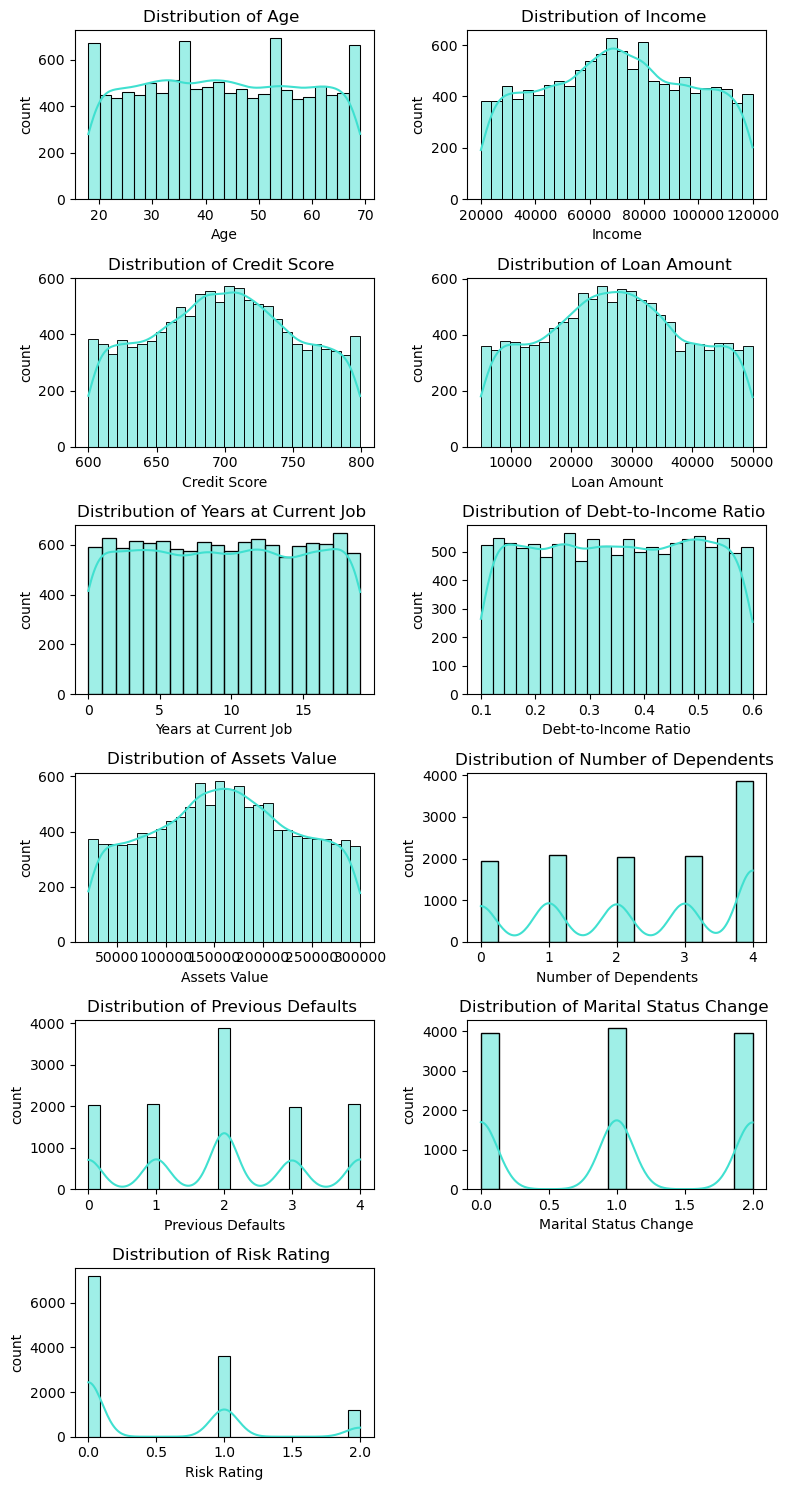

In [56]:
plt.figure(figsize=(8, 15))  
               
for i,col in enumerate(num_cols):
    plt.subplot(6,2,i+1)
    sns.histplot(df_ttest[col],kde=True,color='turquoise')
    plt.title(f"Distribution of {col} ")
    plt.xlabel(col)
    plt.ylabel("count")
    
plt.tight_layout() 
plt.show()

In [76]:
for col in num_cols:
    print(f"{col:20} | Min: {df_train[col].min():8}    | Max: {df_train[col].max():8}")

Age                  | Min:       18    | Max:       69
Income               | Min:  20005.0    | Max: 119997.0
Credit Score         | Min:    600.0    | Max:    799.0
Loan Amount          | Min:   5000.0    | Max:  49998.0
Years at Current Job | Min:        0    | Max:       19
Debt-to-Income Ratio | Min: 0.1000042161056521    | Max: 0.5998844824361803
Assets Value         | Min:  20055.0    | Max: 299999.0
Number of Dependents | Min:      0.0    | Max:      4.0
Previous Defaults    | Min:      0.0    | Max:      4.0
Marital Status Change | Min:        0    | Max:        2
Risk Rating          | Min:        0    | Max:        2


In [80]:
X_train1 = df_train.drop('Risk Rating', axis=1)
y_train1 = df_train['Risk Rating']

X_test1 = df_test.drop('Risk Rating', axis=1)
y_test1 = df_test['Risk Rating']

0:	learn: 0.6000000	total: 181ms	remaining: 1m 30s
100:	learn: 0.6003333	total: 21.4s	remaining: 1m 24s
200:	learn: 0.6037500	total: 46.1s	remaining: 1m 8s
300:	learn: 0.6142500	total: 1m 10s	remaining: 46.5s
400:	learn: 0.6349167	total: 1m 34s	remaining: 23.4s
499:	learn: 0.6613333	total: 1m 59s	remaining: 0us
Top 23 features by importance:
Country                  12.726089
Debt-to-Income Ratio      8.971700
State                     8.203088
Income                    7.990959
Assets Value              7.660396
Loan Amount               7.505378
Credit Score              7.050991
Age                       5.392811
Years at Current Job      4.582423
City                      4.298756
Marital Status            4.144463
Loan Purpose              3.680253
Employment Status         3.564523
Payment History           3.175670
Education Level           3.124651
Gender                    3.054395
Number of Dependents      1.730780
Marital Status Change     1.666265
Previous Defaults         

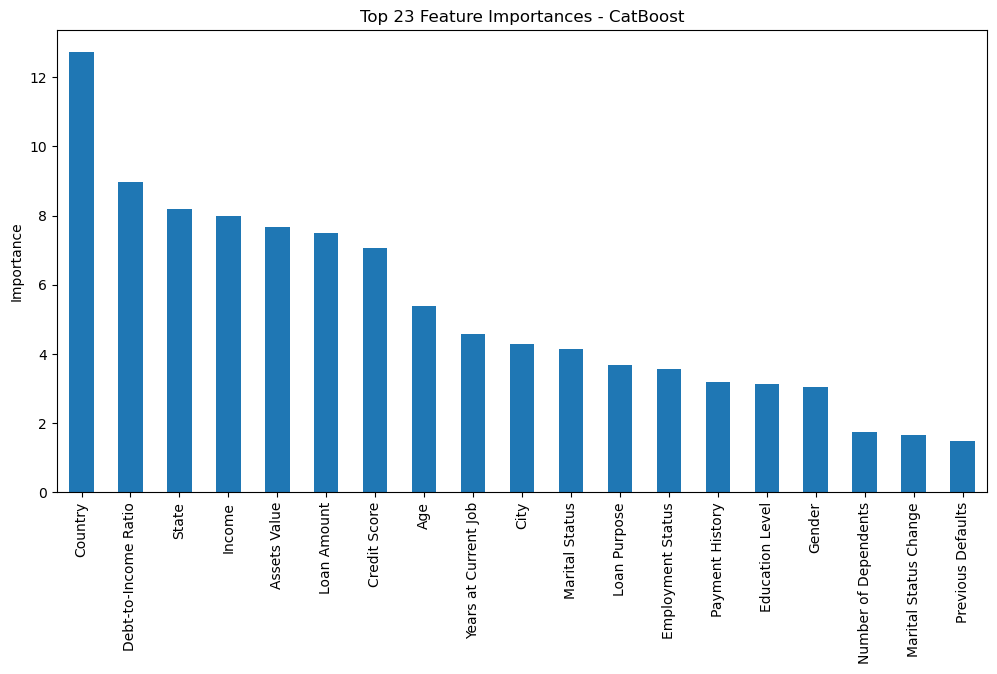

In [82]:
from catboost import CatBoostClassifier, Pool

# Identify categorical columns
cat_cols = X_train1.select_dtypes(include=['object']).columns.tolist()

# Create CatBoost Pool
train_pool = Pool(data=X_train1, label=y_train1, cat_features=cat_cols)

# CatBoost Classifier
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    eval_metric='Accuracy',      
    loss_function='MultiClass', 
    random_seed=42,
    verbose=100
)

# Fit model
cat_model.fit(train_pool)

# Get feature importances
feature_importances = pd.Series(
    cat_model.get_feature_importance(train_pool),index=X_train1.columns).sort_values(ascending=False)

# Show top features
print("Top 23 features by importance:")
print(feature_importances.head(23))

# Plot
plt.figure(figsize=(12,6))
feature_importances.head(23).plot(kind='bar')
plt.title("Top 23 Feature Importances - CatBoost")
plt.ylabel("Importance")
plt.show()


In [266]:
# for encoding the data i will use mapping for ordinal features whereas for nominal features i will be using one-hot encoding 
# but looking at each nominal feature's unique values, i have noticed city has very high cardinality
# which will cause huge amounts of new columns and ruin the training process
# so i decided to drop it and keep the State and city columns as the geographical reference in my dataset

In [92]:
df_train = df_train.drop(columns="City")
df_test = df_test.drop(columns="City")

In [122]:
X_train2 = df_train.drop('Risk Rating', axis=1)
y_train2 = df_train['Risk Rating']

X_test2 = df_test.drop('Risk Rating', axis=1)
y_test2 = df_test['Risk Rating']

In [142]:
for col in ['State', 'Country']:
    freq = df_train[col].value_counts() / len(df_train)
    df_train[col] = df_train[col].map(freq)
    df_test[col] = df_test[col].map(freq)

In [146]:
# encoding the only ordinal feature left
payment_order = {"Poor": 0, "Fair": 1, "Good": 2, "Excellent": 3}

# encode on train and test parts seperately
df_train["Payment History"] = df_train["Payment History"].map(payment_order)
df_test["Payment History"] = df_test["Payment History"].map(payment_order)

In [152]:
# seperating the nominal features
nominal_cols = [ "Gender","Education Level", "Marital Status", "Loan Purpose","Employment Status"]

In [158]:
df_train_final = pd.get_dummies(df_train, columns=nominal_cols, drop_first=True)

In [160]:
df_test_final = pd.get_dummies(df_test, columns=nominal_cols, drop_first=True)

In [208]:
X_train = df_train_final.drop('Risk Rating', axis=1)
y_train = df_train_final['Risk Rating']

X_test = df_test_final.drop('Risk Rating', axis=1)
y_test = df_test_final['Risk Rating']

In [218]:
from sklearn.preprocessing import StandardScaler

num_cols_to_scale = ['Income', 'Loan Amount', 'Assets Value', 'Age', 'Credit Score', 'Years at Current Job']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])


# Learning Curves

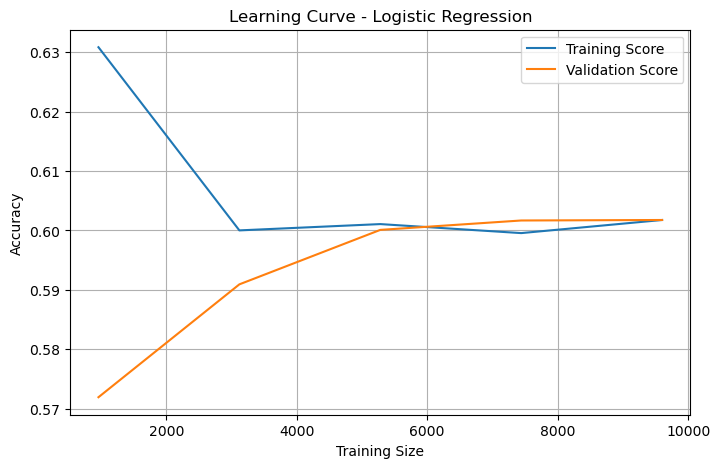

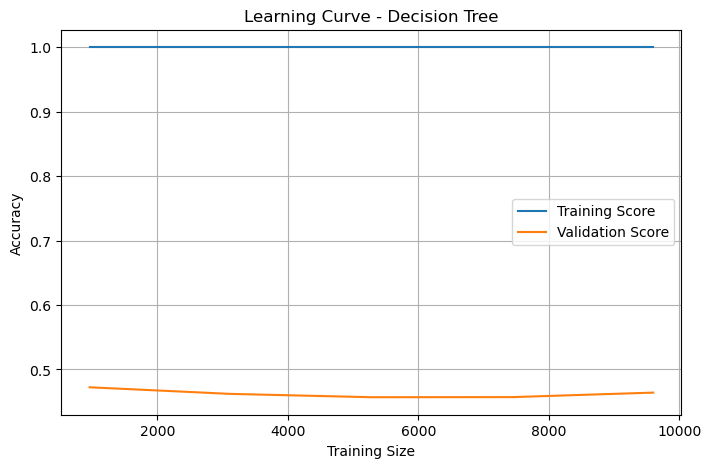

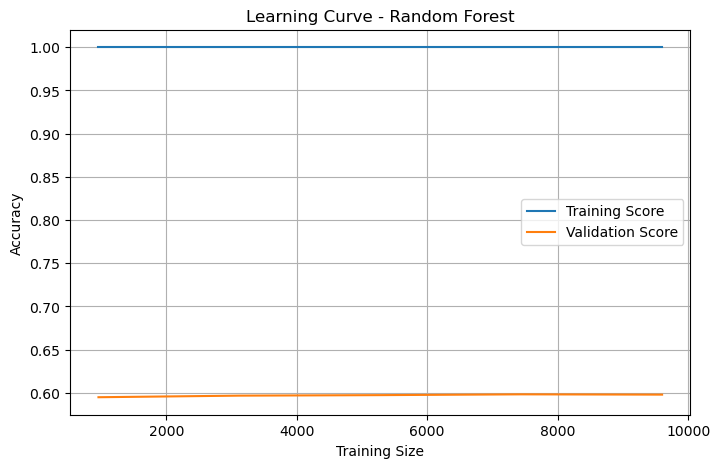

In [104]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
    plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation Score')
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot curves for your 3 models
plot_learning_curve(LogisticRegression(max_iter=2000), X_train, y_train, "Learning Curve - Logistic Regression")
plot_learning_curve(DecisionTreeClassifier(), X_train, y_train, "Learning Curve - Decision Tree")
plot_learning_curve(RandomForestClassifier(), X_train, y_train, "Learning Curve - Random Forest")

In [ ]:
# after plotting the learning curves for the pure models without any tuning, i will be using RandomizedSearchCV to get the best hyperparamaters for 
# each model instead of manually making changes (also it is faster than GridSearchCV because you can control the no. of iterations it makes)

In [94]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

lr1 = LogisticRegression(max_iter=300)

lr_dist = {
    'C': stats.uniform(0.01, 10),
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_random = RandomizedSearchCV(
    lr1,
    lr_dist,
    n_iter=10,   # tries only 10 combinations
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

lr_random.fit(X_train, y_train)
print(lr_random.best_params_)


{'C': 0.5908361216819946, 'class_weight': 'balanced', 'solver': 'lbfgs'}


In [100]:
print(lr_random.best_score_)

0.29106600697185775


In [118]:
best_lr_model = lr_random.best_estimator_

In [102]:
# Base model
dt1 = DecisionTreeClassifier(random_state=42)

# Hyperparameter distributions
dt_dist = {
    'max_depth': np.arange(4, 25),           # try trees of depth 4 to 24
    'min_samples_split': np.arange(2, 50, 2), # must have at least N samples to split
    'min_samples_leaf': np.arange(1, 20),     # minimum samples per leaf
    'criterion': ['gini', 'entropy'],         # how splits are evaluated
    'class_weight': [None, 'balanced']        # try balancing classes
}

# Randomized Search
dt_random = RandomizedSearchCV(
    estimator=dt1,
    param_distributions=dt_dist,
    n_iter=30,                   # tries 30 random combinations
    scoring='f1_macro',          # best metric for imbalanced multi-class
    cv=5,                        # 5-fold cross validation
    random_state=42,
    n_jobs=-1                    # use all CPU cores
)

# Fit on training data
dt_random.fit(X_train, y_train)

print("Best parameters for Decision Tree:")
print(dt_random.best_params_)

print("Best cross-validation F1-macro:")
print(dt_random.best_score_)

Best parameters for Decision Tree:
{'min_samples_split': 14, 'min_samples_leaf': 11, 'max_depth': 24, 'criterion': 'entropy', 'class_weight': None}
Best cross-validation F1-macro:
0.32854630527543305


In [120]:
best_dt_model = dt_random.best_estimator_

In [96]:
rf_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [6, 10, 14, 18],
    'min_samples_split': [2, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(),
    rf_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
print(rf_random.best_params_)


{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 10}


In [98]:
print(rf_random.best_score_)

0.2506644880089751


In [122]:
best_rf_model = rf_random.best_estimator_

In [ ]:
# now i have saved all the tuned models, i will replot the learning curves for each tuned model to compare the difference 

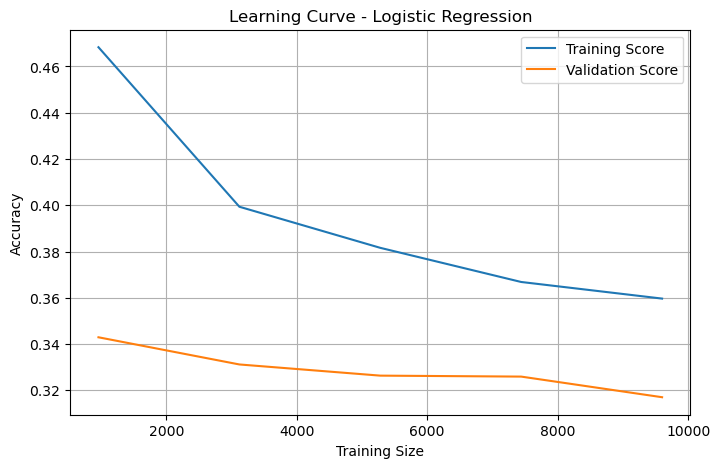

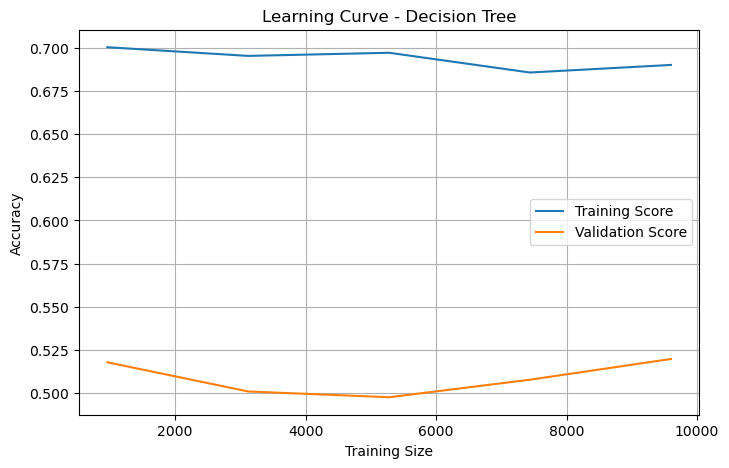

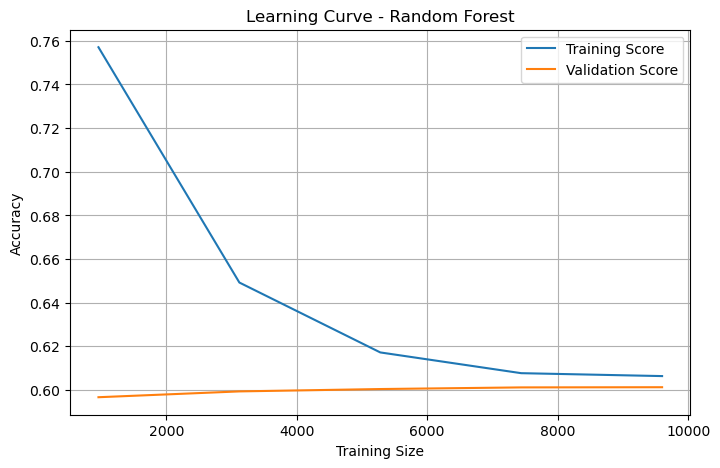

In [124]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
    plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation Score')
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot curves for your 3 models
plot_learning_curve(best_lr_model, X_train, y_train, "Learning Curve - Logistic Regression")
plot_learning_curve(best_dt_model, X_train, y_train, "Learning Curve - Decision Tree")
plot_learning_curve(best_rf_model, X_train, y_train, "Learning Curve - Random Forest")

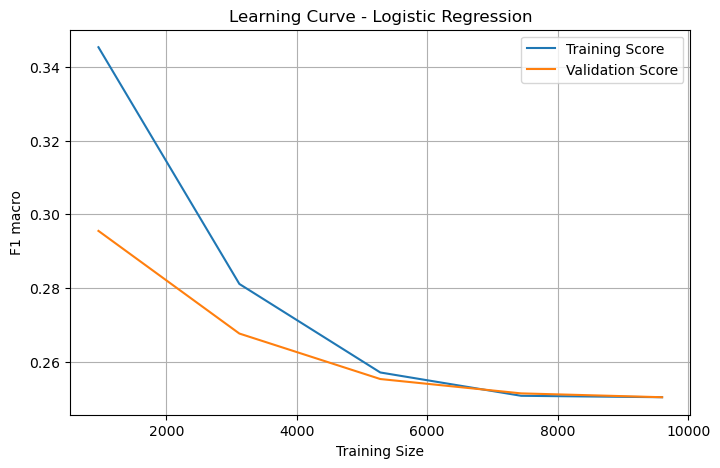

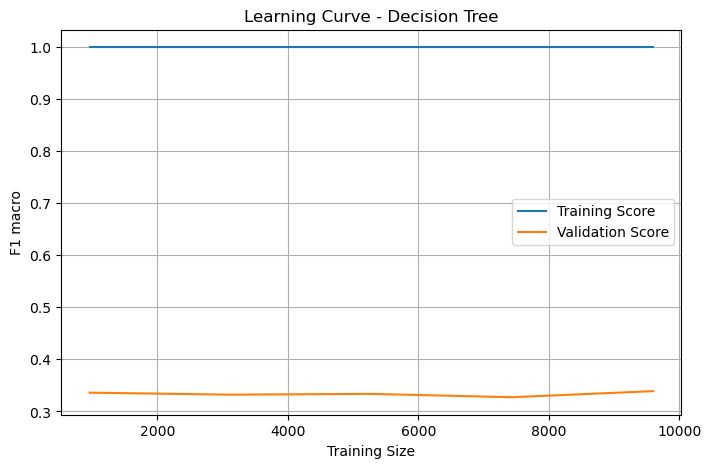

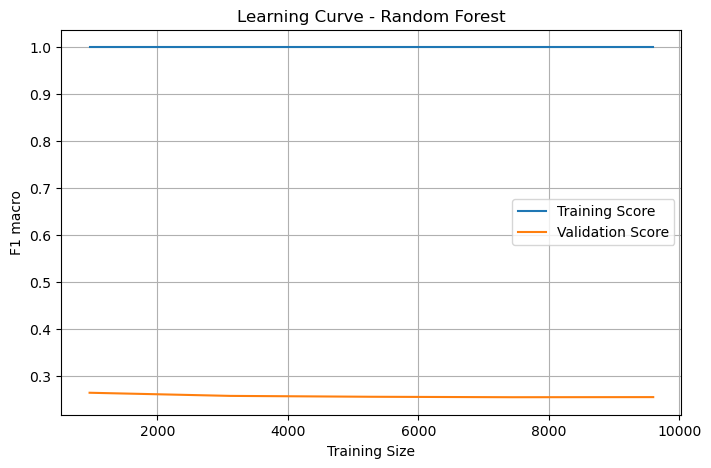

In [157]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
    plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation Score')
    plt.xlabel("Training Size")
    plt.ylabel("F1 macro")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot curves for your 3 models
plot_learning_curve(LogisticRegression(max_iter=2000), X_train, y_train, "Learning Curve - Logistic Regression")
plot_learning_curve(DecisionTreeClassifier(), X_train, y_train, "Learning Curve - Decision Tree")
plot_learning_curve(RandomForestClassifier(), X_train, y_train, "Learning Curve - Random Forest")

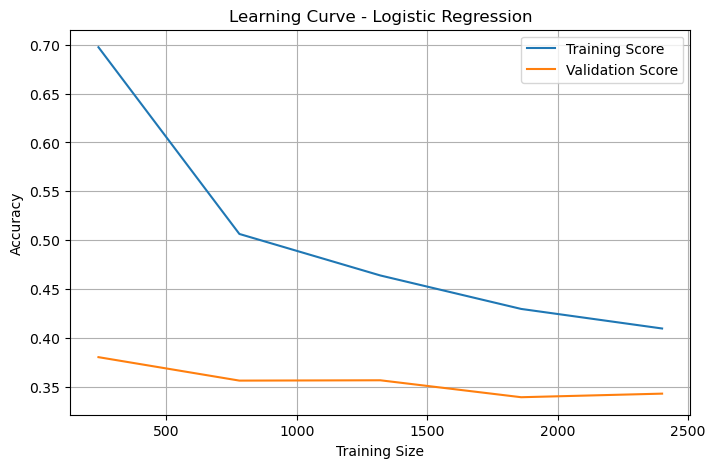

In [151]:
# Plot curves for your 3 models
plot_learning_curve(best_lr_model, X_test, y_test, "Learning Curve - Logistic Regression")
#plot_learning_curve(best_dt_model, X_train, y_train, "Learning Curve - Decision Tree")
#plot_learning_curve(best_rf_model, X_train, y_train, "Learning Curve - Random Forest")

# Evaluating the models

Evaluation Report for: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.31      0.41      1779
           1       0.32      0.35      0.33       895
           2       0.12      0.43      0.19       326

    accuracy                           0.33      3000
   macro avg       0.35      0.36      0.31      3000
weighted avg       0.47      0.33      0.36      3000

ROC-AUC (OVR): 0.5181054583382324

Confusion Matrix:
[[544 574 661]
 [252 311 332]
 [ 86 101 139]]


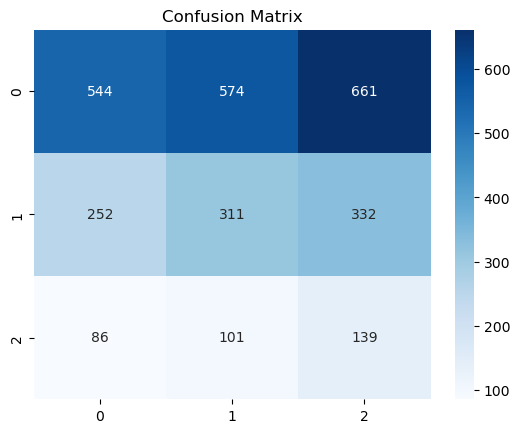

Evaluation Report for: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.72      0.65      1779
           1       0.30      0.24      0.27       895
           2       0.05      0.02      0.02       326

    accuracy                           0.50      3000
   macro avg       0.31      0.33      0.31      3000
weighted avg       0.44      0.50      0.47      3000

ROC-AUC (OVR): 0.4996115878287782

Confusion Matrix:
[[1284  430   65]
 [ 642  214   39]
 [ 249   72    5]]


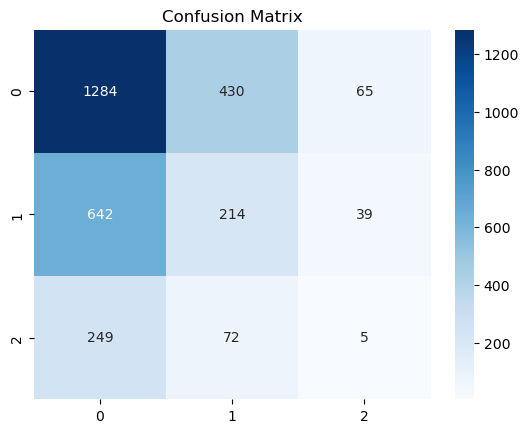

Evaluation Report for: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.59      1.00      0.74      1779
           1       0.00      0.00      0.00       895
           2       0.00      0.00      0.00       326

    accuracy                           0.59      3000
   macro avg       0.20      0.33      0.25      3000
weighted avg       0.35      0.59      0.44      3000

ROC-AUC (OVR): 0.5063965187476716

Confusion Matrix:
[[1779    0    0]
 [ 895    0    0]
 [ 326    0    0]]


D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


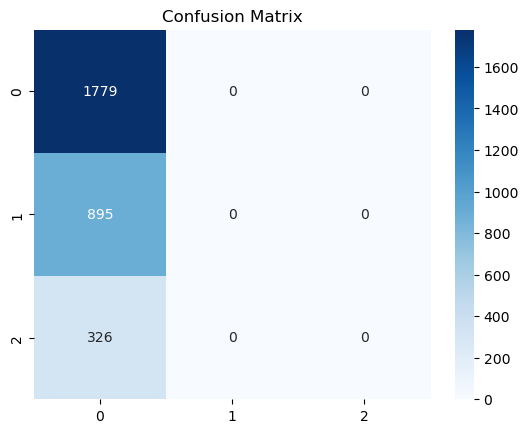

In [134]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    print("="*60)
    print(f"Evaluation Report for: {model_name}")
    print("="*60)
    
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ROC-AUC for multiclass requires 'ovr'
    try:
        auc = roc_auc_score(y_test, y_probs, multi_class='ovr')
        print("ROC-AUC (OVR):", auc)
    except:
        print("ROC-AUC could not be computed.")
        
    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

  

evaluate_model(best_lr_model, X_test, y_test, "Logistic Regression")
evaluate_model(best_dt_model, X_test, y_test, "Decision Tree")
evaluate_model(best_rf_model, X_test, y_test, "Random Forest")



In [137]:
from imblearn.over_sampling import SMOTE

# Before SMOTE
print("Before SMOTE:", y_train.value_counts())

# Apply SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# After SMOTE
print("After SMOTE:", y_train_sm.value_counts())


Before SMOTE: Risk Rating
0    7221
1    3605
2    1174
Name: count, dtype: int64
After SMOTE: Risk Rating
1    7221
0    7221
2    7221
Name: count, dtype: int64


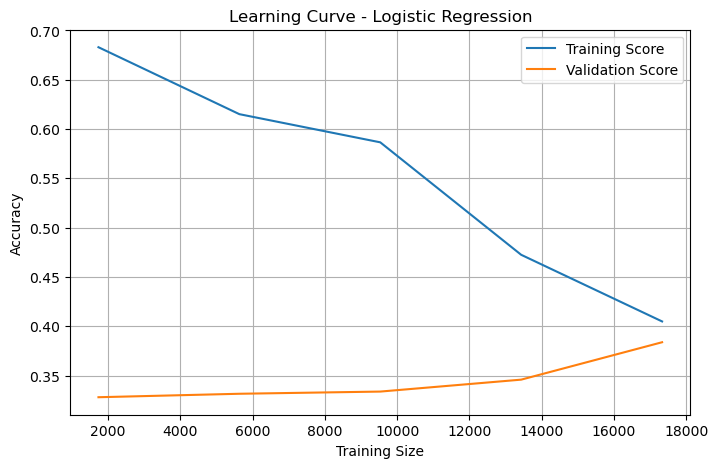

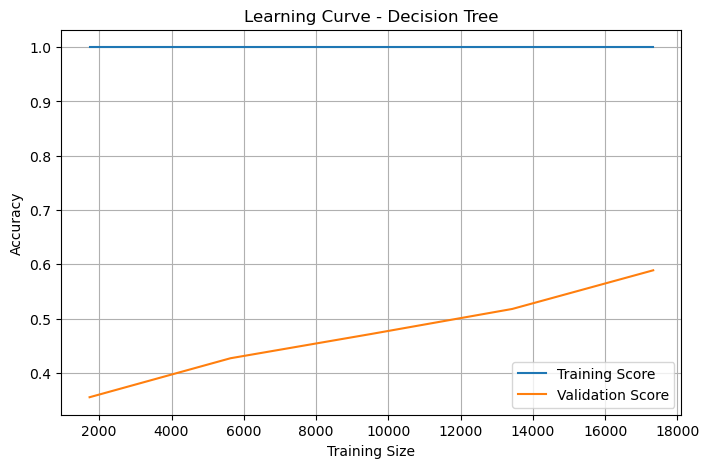

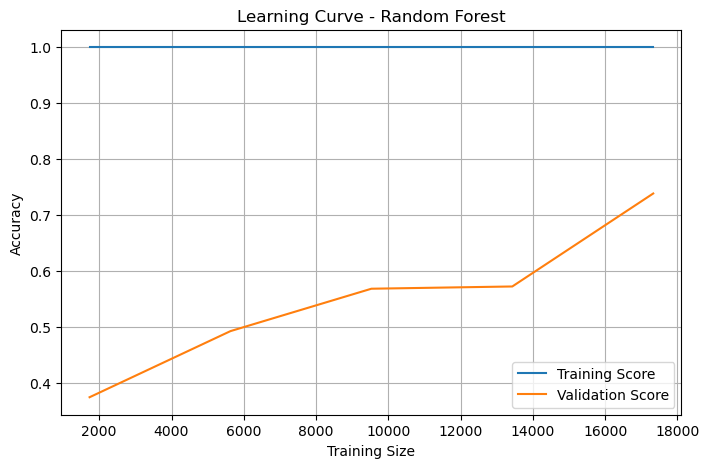

In [139]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
    plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation Score')
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot curves for your 3 models
plot_learning_curve(LogisticRegression(max_iter=2000), X_train_sm, y_train_sm, "Learning Curve - Logistic Regression")
plot_learning_curve(DecisionTreeClassifier(), X_train_sm, y_train_sm, "Learning Curve - Decision Tree")
plot_learning_curve(RandomForestClassifier(), X_train_sm, y_train_sm, "Learning Curve - Random Forest")

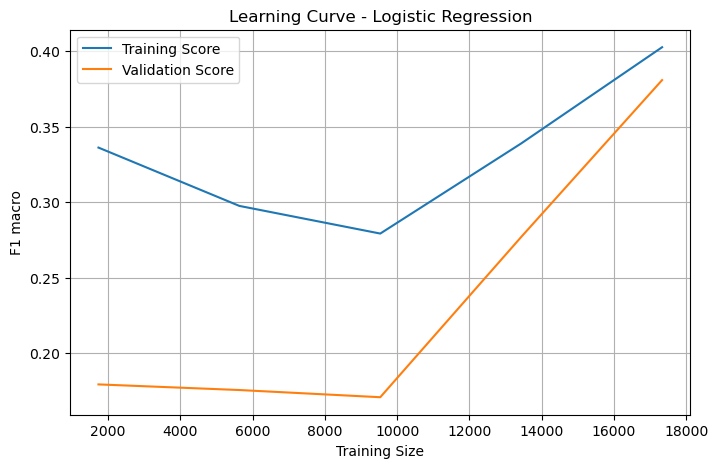

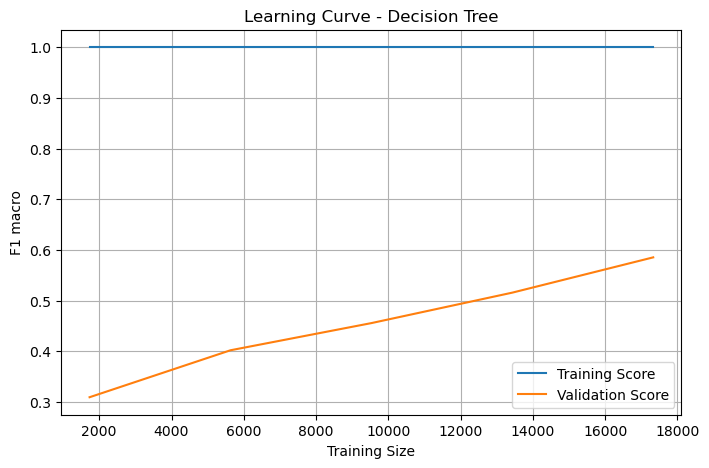

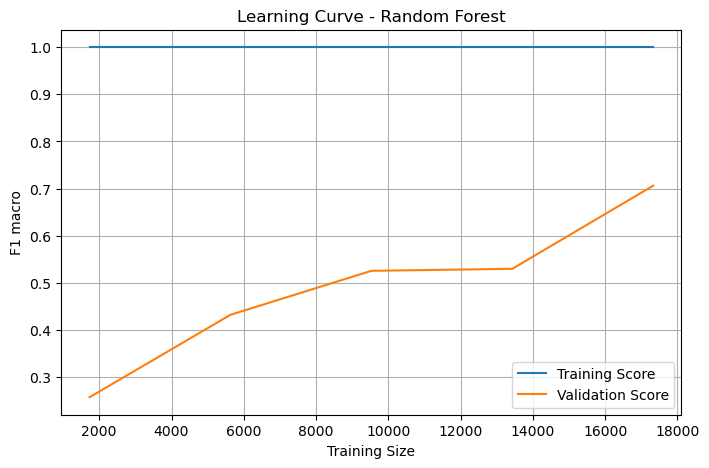

In [153]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring='f1_macro',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
    plt.plot(train_sizes, test_scores.mean(axis=1), label='Validation Score')
    plt.xlabel("Training Size")
    plt.ylabel("F1 macro")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot curves for your 3 models
plot_learning_curve(LogisticRegression(max_iter=2000), X_train_sm, y_train_sm, "Learning Curve - Logistic Regression")
plot_learning_curve(DecisionTreeClassifier(), X_train_sm, y_train_sm, "Learning Curve - Decision Tree")
plot_learning_curve(RandomForestClassifier(), X_train_sm, y_train_sm, "Learning Curve - Random Forest")

In [145]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

lr2 = LogisticRegression(max_iter=300)

lr_dist1 = {
    'C': stats.uniform(0.01, 10),
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_random1 = RandomizedSearchCV(
    lr2,
    lr_dist1,
    n_iter=10,   # tries only 10 combinations
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

lr_random1.fit(X_train_sm, y_train_sm)

print("Best parameters for LR:")
print(lr_random1.best_params_)
print("Best cross-validation F1-macro:")
print(lr_random1.best_score_)

Best parameters for LR:
{'C': 8.334426408004218, 'class_weight': 'balanced', 'solver': 'liblinear'}
Best cross-validation F1-macro:
0.3814710455969995


In [147]:
best_lr_model_sm  = lr_random1.best_estimator_

In [149]:
# Base model
dt2 = DecisionTreeClassifier(random_state=42)

# Hyperparameter distributions
dt_dist1 = {
    'max_depth': np.arange(4, 25),           # try trees of depth 4 to 24
    'min_samples_split': np.arange(2, 50, 2), # must have at least N samples to split
    'min_samples_leaf': np.arange(1, 20),     # minimum samples per leaf
    'criterion': ['gini', 'entropy'],         # how splits are evaluated
    'class_weight': [None, 'balanced']        # try balancing classes
}

# Randomized Search
dt_random1 = RandomizedSearchCV(
    estimator=dt2,
    param_distributions=dt_dist1,
    n_iter=30,                   # tries 30 random combinations
    scoring='f1_macro',          # best metric for imbalanced multi-class
    cv=5,                        # 5-fold cross validation
    random_state=42,
    n_jobs=-1                    # use all CPU cores
)

# Fit on training data
dt_random1.fit(X_train_sm, y_train_sm)

print("Best parameters for Decision Tree:")
print(dt_random1.best_params_)

print("Best cross-validation F1-macro:")
print(dt_random1.best_score_)

Best parameters for Decision Tree:
{'min_samples_split': 2, 'min_samples_leaf': 6, 'max_depth': 22, 'criterion': 'gini', 'class_weight': 'balanced'}
Best cross-validation F1-macro:
0.5530461020524162


In [ ]:
rf_dist1 = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [6, 10, 14, 18],
    'min_samples_split': [2, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None]
}

rf_random1 = RandomizedSearchCV(
    RandomForestClassifier(),
    rf_dist1,
    n_iter=20,
    scoring='f1_macro',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_random1.fit(X_train_sm, y_train_sm)
print("Best parameters for RF:")
print(rf_random.best_params_)
print("Best cross-validation F1-macro:")
print(rf_random.best_score_)

In [ ]:
best_rf_model = rf_random.best_estimator_